# 🛡️ Ransomware Detection Model Training

This notebook trains a machine learning model to detect ransomware and malware using PE file features.

## Dataset Overview
- **PE_Header.csv**: PE header features
- **PE_Section.csv**: Section-level features
- **DLLs_Imported.csv**: Imported DLL information
- **API_Functions.csv**: API function calls

## Target Classes
- 0: Benign
- 1-6: Different malware types

## 1️⃣ Import Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Model persistence
import pickle
import joblib

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2️⃣ Load Datasets

In [3]:
# Load all dataset files
pe_header = pd.read_csv('new_dataset/PE_Header.csv')
pe_section = pd.read_csv('new_dataset/PE_Section.csv')
dlls_imported = pd.read_csv('new_dataset/DLLs_Imported.csv')


print("Dataset Shapes:")
print(f"  PE Header:      {pe_header.shape}")
print(f"  PE Section:     {pe_section.shape}")
print(f"  DLLs Imported:  {dlls_imported.shape}")


Dataset Shapes:
  PE Header:      (29807, 54)
  PE Section:     (29760, 92)
  DLLs Imported:  (29498, 631)


In [4]:
# Preview PE Header data
print("PE Header - First 5 rows:")
pe_header.head()

PE Header - First 5 rows:


,SHA256,Type,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,...,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes
0,dacbe8cb72dd746539792a50e84965fefef73feaa07b5d...,0,23117,144,3,0,4,0,65535,0,...,139264,4096,0,2,1344,1048576,1048576,4096,0,16
1,d3dc7512ce75db33b2c3063fa99245e9ca9fe3b086462f...,0,23117,144,3,0,4,0,65535,0,...,49152,512,0,2,34112,1048576,1048576,4096,0,16
2,b350fac81533f02981dc2176ed17163177d92d9405758e...,0,23117,144,3,0,4,0,65535,0,...,532480,512,0,2,34144,1048576,1048576,4096,0,16
3,dfee618043a47b7b09305df0ca460559d9f567ee246c7b...,0,23117,144,3,0,4,0,65535,0,...,1368064,4096,1366781,2,1024,1048576,1048576,4096,0,16
4,c7b2e4e4fb2fcc44c953673ff57c3d14bdf5d2008f35e9...,0,23117,144,3,0,4,0,65535,0,...,32768,512,64362,2,1344,1048576,1048576,4096,0,16



Target (Type) Distribution:
Type
0    1877
1    5047
2    4864
3    4973
4    5104
5    4236
6    3706
Name: count, dtype: int64


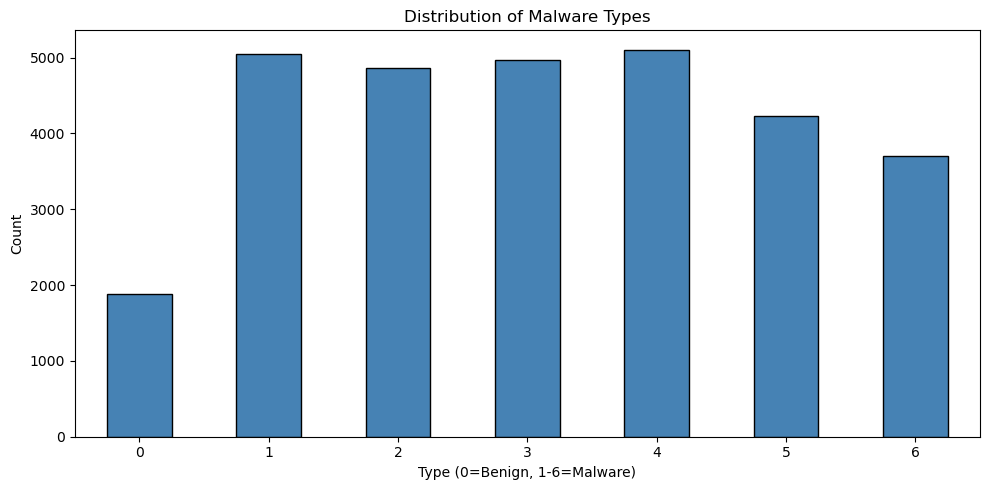

In [5]:
# Check target distribution
print("\nTarget (Type) Distribution:")
print(pe_header['Type'].value_counts().sort_index())

plt.figure(figsize=(10, 5))
pe_header['Type'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Malware Types')
plt.xlabel('Type (0=Benign, 1-6=Malware)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3️⃣ Merge Datasets

In [6]:
# Merge all datasets on SHA256
# Start with PE Header as base
df = pe_header.copy()

# Merge PE Section (drop duplicate columns)
pe_section_cols = [col for col in pe_section.columns if col not in ['Type']]
df = df.merge(pe_section[pe_section_cols], on='SHA256', how='left')

# Merge DLLs Imported
dlls_cols = [col for col in dlls_imported.columns if col not in ['Type']]
df = df.merge(dlls_imported[dlls_cols], on='SHA256', how='left')

# Merge API Functions

print(f"\n✅ Merged dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 2}  (excluding SHA256 and Type)")


✅ Merged dataset shape: (29810, 773)
Total features: 771  (excluding SHA256 and Type)


## 4️⃣ Data Preprocessing

In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print(f"❌ Found {len(missing_df)} columns with missing values")
    print(missing_df.head(10))
else:
    print("✅ No missing values found!")

❌ Found 719 columns with missing values
                                                  Missing   Percent
scnpst32.dll                                          313  1.049983
api-ms-win-core-timezone-private-l1-1-0.dll           313  1.049983
dwmapi.dll                                            313  1.049983
wbemcomn.dll                                          313  1.049983
api-ms-win-core-registry-l2-2-0.dll                   313  1.049983
api-ms-win-core-shlwapi-obsolete-l1-2-0.dll           313  1.049983
api-ms-win-core-localization-obsolete-l1-3-0.dll      313  1.049983
api-ms-win-core-version-l1-1-0.dll                    313  1.049983
mswsock.dll                                           313  1.049983
api-ms-win-core-file-l2-1-1.dll                       313  1.049983


In [8]:
# Fill missing values with 0 (common for PE features)
df = df.fillna(0)

# Create binary target: 0 = Benign, 1 = Malware (any type)
df['is_malware'] = (df['Type'] > 0).astype(int)

print("Binary Target Distribution:")
print(df['is_malware'].value_counts())
print(f"\nBenign:  {(df['is_malware'] == 0).sum()} ({(df['is_malware'] == 0).mean()*100:.1f}%)")
print(f"Malware: {(df['is_malware'] == 1).sum()} ({(df['is_malware'] == 1).mean()*100:.1f}%)")

Binary Target Distribution:
is_malware
1    27933
0     1877
Name: count, dtype: int64

Benign:  1877 (6.3%)
Malware: 27933 (93.7%)


In [9]:
# Prepare features and target
# Drop non-feature columns
drop_cols = ['SHA256', 'Type', 'is_malware']
feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols]
y = df['is_malware']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols[:20], "..." if len(feature_cols) > 20 else "")

Features shape: (29810, 771)
Target shape:   (29810,)

Feature columns (771):
['e_magic', 'e_cblp', 'e_cp', 'e_crlc', 'e_cparhdr', 'e_minalloc', 'e_maxalloc', 'e_ss', 'e_sp', 'e_csum', 'e_ip', 'e_cs', 'e_lfarlc', 'e_ovno', 'e_oemid', 'e_oeminfo', 'e_lfanew', 'Machine', 'NumberOfSections', 'TimeDateStamp'] ...


## 5️⃣ Feature Selection

In [10]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold

# Remove features with very low variance
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

print(f"Original features:      {X.shape[1]}")
print(f"After variance filter:  {len(selected_features)}")
print(f"Removed:                {X.shape[1] - len(selected_features)} low-variance features")

Original features:      771
After variance filter:  158
Removed:                613 low-variance features


In [11]:
# Select top K features using mutual information
X_filtered = X[selected_features]

# Use SelectKBest with mutual information
k_features = min(50, len(selected_features))  # Select top 50 or all if less
selector_kbest = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_selected = selector_kbest.fit_transform(X_filtered, y)

# Get selected feature names
selected_mask = selector_kbest.get_support()
final_features = [f for f, s in zip(selected_features, selected_mask) if s]

print(f"\n✅ Selected top {k_features} features using Mutual Information")
print(f"Final feature count: {len(final_features)}")


✅ Selected top 50 features using Mutual Information
Final feature count: 50


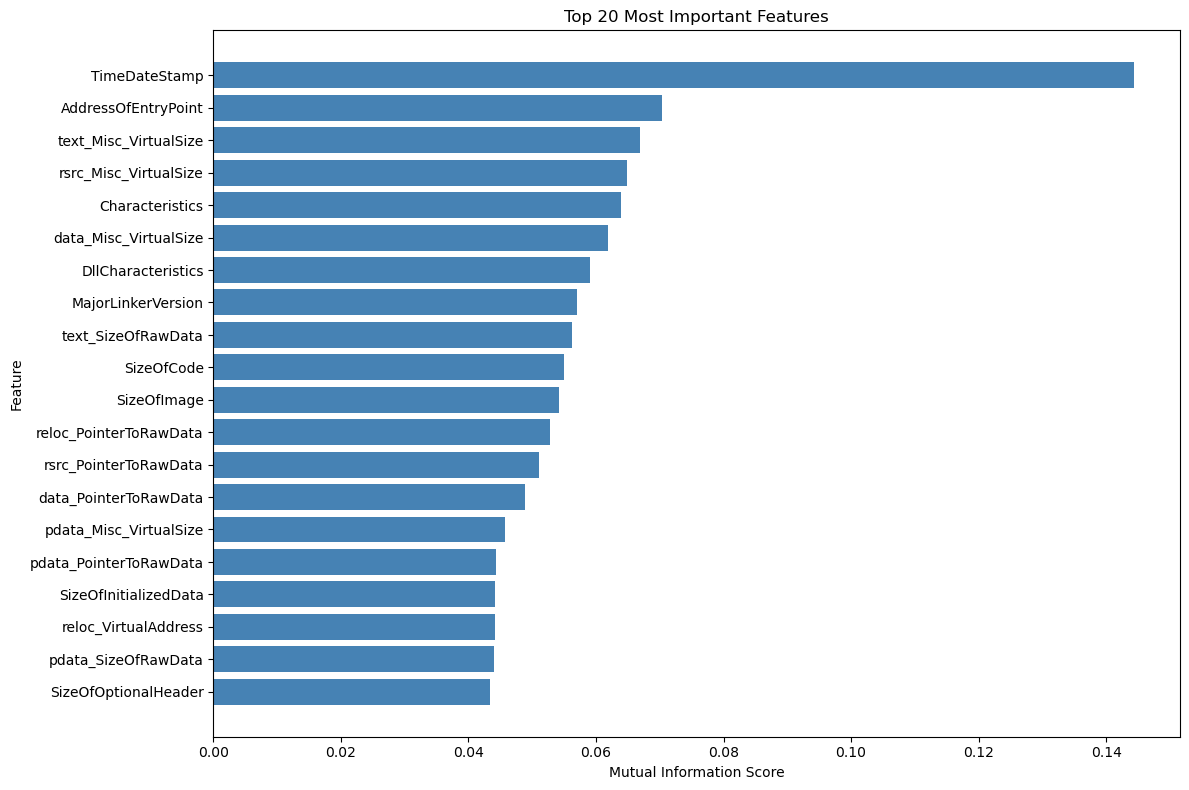

In [12]:
# Visualize feature importance
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'Score': selector_kbest.scores_
}).sort_values('Score', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_scores['Feature'].head(20), feature_scores['Score'].head(20), color='steelblue')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6️⃣ Train-Test Split

In [13]:
# Prepare final feature matrix
X_final = X[final_features]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 23848 samples
Test set:     5962 samples

Training class distribution:
is_malware
1    22346
0     1502
Name: count, dtype: int64


In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")

✅ Features scaled using StandardScaler


## 7️⃣ Model Training & Comparison

In [15]:
# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

print(f"Training {len(models)} models...")

Training 6 models...


In [16]:
# Train and evaluate all models
results = []

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Use scaled data for models that need it
    if name in ['Logistic Regression', 'KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    
    print(f"  ✅ Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
results_df


🔄 Training Random Forest...
  ✅ Accuracy: 0.9911 | F1: 0.9953 | AUC: 0.9971

🔄 Training XGBoost...
  ✅ Accuracy: 0.9933 | F1: 0.9964 | AUC: 0.9965

🔄 Training Gradient Boosting...
  ✅ Accuracy: 0.9896 | F1: 0.9945 | AUC: 0.9903

🔄 Training Decision Tree...
  ✅ Accuracy: 0.9881 | F1: 0.9936 | AUC: 0.9625

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.9602 | F1: 0.9791 | AUC: 0.9280

🔄 Training KNN...
  ✅ Accuracy: 0.9847 | F1: 0.9919 | AUC: 0.9651

MODEL COMPARISON RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,XGBoost,0.993291,0.995710,0.997136,0.996423,0.996489
0,Random Forest,0.991110,0.994284,0.996241,0.995262,0.997099
2,Gradient Boosting,0.989601,0.992161,0.996778,0.994464,0.990279
3,Decision Tree,0.988091,0.995508,0.991767,0.993634,0.962550
5,KNN,0.984737,0.989491,0.994272,0.991876,0.965054
4,Logistic Regression,0.960248,0.964894,0.993735,0.979102,0.927976


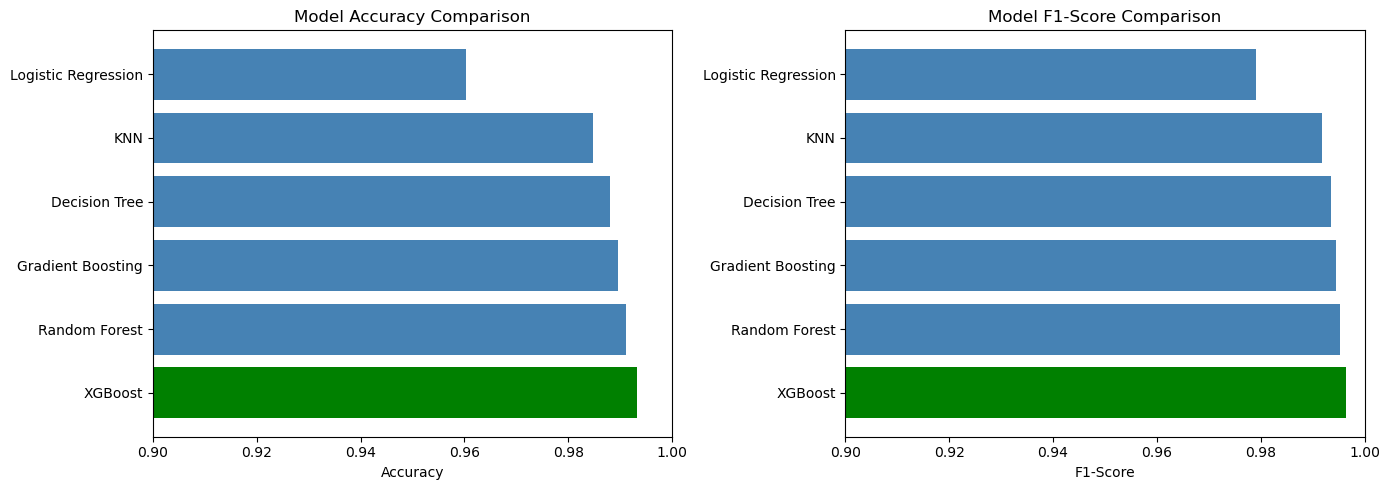

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
colors = ['green' if x == results_df['Accuracy'].max() else 'steelblue' for x in results_df['Accuracy']]
ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlim(0.9, 1.0)

# F1-Score comparison
ax2 = axes[1]
colors = ['green' if x == results_df['F1-Score'].max() else 'steelblue' for x in results_df['F1-Score']]
ax2.barh(results_df['Model'], results_df['F1-Score'], color=colors)
ax2.set_xlabel('F1-Score')
ax2.set_title('Model F1-Score Comparison')
ax2.set_xlim(0.9, 1.0)

plt.tight_layout()
plt.show()

## 8️⃣ Best Model - Hyperparameter Tuning

In [18]:
# Select best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"🏆 Best performing model: {best_model_name}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

🏆 Best performing model: XGBoost
   F1-Score: 0.9964


In [19]:
# Hyperparameter tuning for Random Forest
print("🔧 Hyperparameter Tuning for Random Forest...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use RandomizedSearchCV for faster tuning
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    rf, param_grid, n_iter=20, cv=3, 
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best parameters: {random_search.best_params_}")
print(f"   Best CV F1-Score: {random_search.best_score_:.4f}")

🔧 Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
   Best CV F1-Score: 0.9950


In [20]:
# Train final model with best parameters
best_model = random_search.best_estimator_

# Final evaluation
y_pred_final = best_model.predict(X_test)
y_pred_proba_final = best_model.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_final):.4f}")


FINAL MODEL EVALUATION

Accuracy:  0.9914
Precision: 0.9938
Recall:    0.9971
F1-Score:  0.9954
AUC-ROC:   0.9971


In [21]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Benign', 'Malware']))


Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.91      0.93       375
     Malware       0.99      1.00      1.00      5587

    accuracy                           0.99      5962
   macro avg       0.97      0.95      0.96      5962
weighted avg       0.99      0.99      0.99      5962



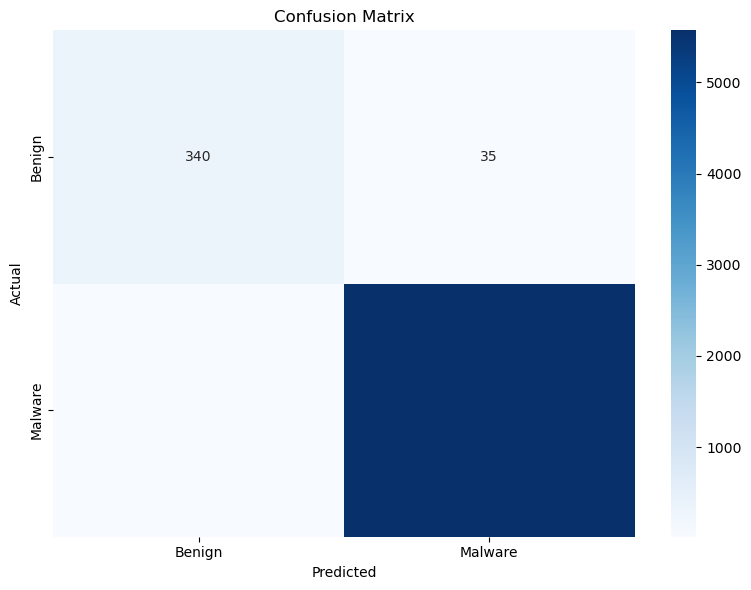

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malware'], 
            yticklabels=['Benign', 'Malware'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

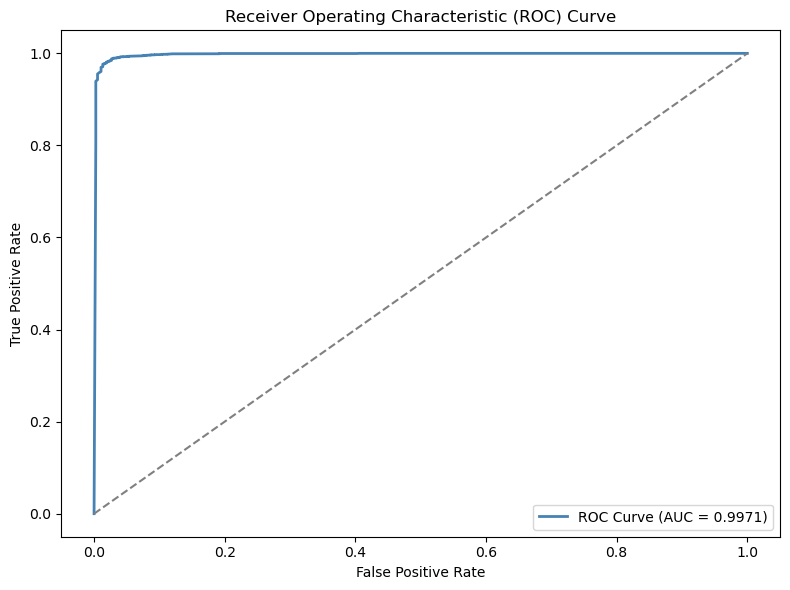

In [23]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
auc = roc_auc_score(y_test, y_pred_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9️⃣ Feature Importance Analysis

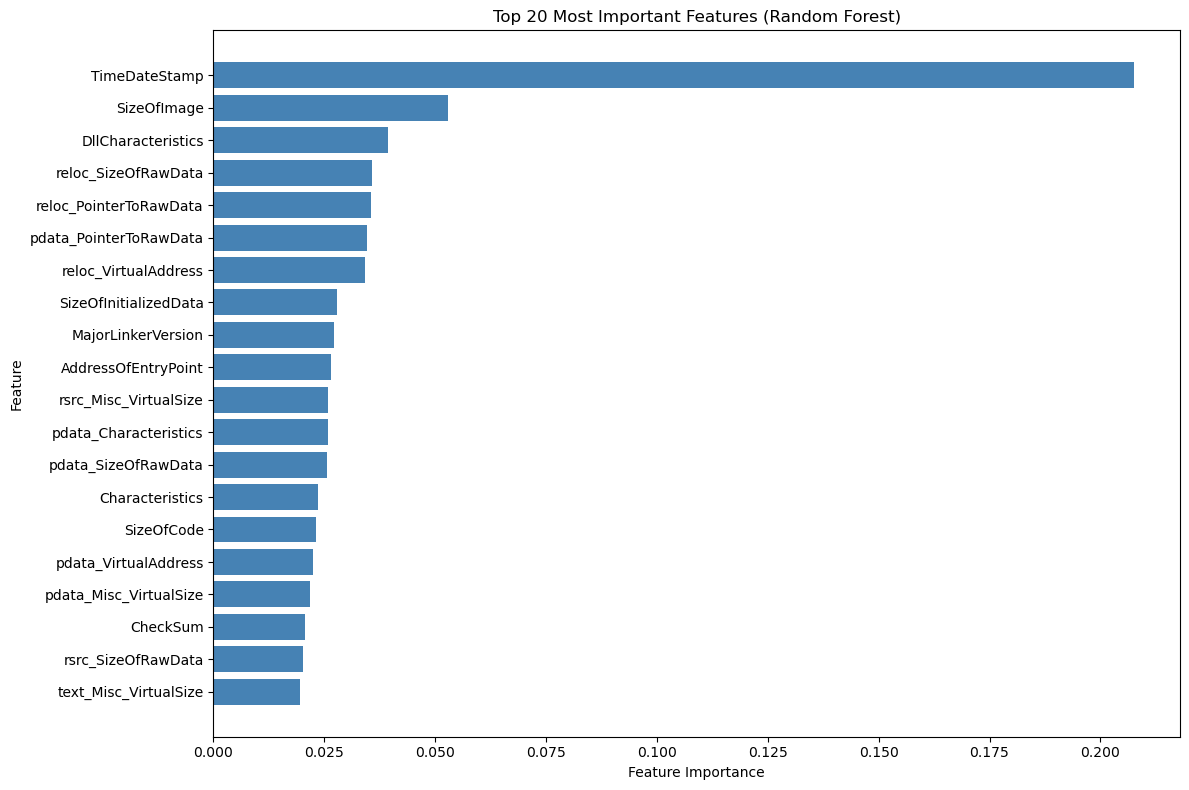

In [24]:
# Get feature importances from the best model
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'].head(20), 
         feature_importance_df['Importance'].head(20), 
         color='steelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 🔟 Save Model

In [25]:
# Save the trained model
model_path = 'ransomware_rf_model_new.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"✅ Model saved to: {model_path}")

# Save feature list
feature_path = 'model_features.pkl'
with open(feature_path, 'wb') as f:
    pickle.dump(final_features, f)

print(f"✅ Feature list saved to: {feature_path}")

# Save scaler (if needed)
scaler_path = 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Scaler saved to: {scaler_path}")

✅ Model saved to: ransomware_rf_model_new.pkl
✅ Feature list saved to: model_features.pkl
✅ Scaler saved to: scaler.pkl


In [26]:
# Verify saved model
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

# Test prediction
test_pred = loaded_model.predict(X_test.head(5))
print("\n✅ Model verified - Sample predictions:")
print(f"   Predictions: {test_pred}")
print(f"   Actual:      {y_test.head(5).values}")


✅ Model verified - Sample predictions:
   Predictions: [1 1 1 1 1]
   Actual:      [1 1 1 1 1]


## 📊 Summary

### Model Performance
- **Best Model**: Random Forest (Tuned)
- **Features Used**: Selected top features based on mutual information

### Files Saved
1. `ransomware_rf_model_new.pkl` - Trained model
2. `model_features.pkl` - List of feature names
3. `scaler.pkl` - StandardScaler for feature scaling

### Next Steps
1. Update the backend to use the new model
2. Update feature extraction to match the new feature set
3. Test with real-world PE files